In [18]:
##系统报错改为英文
Sys.setenv(LANGUAGE = "en")
##禁止转化为因子
options(stringsAsFactors = FALSE)
##清空环境
rm(list=ls())

setwd("/Users/a1-6/Documents/projects/DL/97-bioinformatics/gene_process_for_python/single-cell-rna")
###加载所需要的包
library(Seurat)
library(tidyverse)
library(dplyr)
library(patchwork)
library(harmony)


In [19]:
scRNA.11=Read10X("data/GSE152048/BC2/")
scRNA.3=Read10X("data/GSE152048/BC21/")
scRNA.11 = CreateSeuratObject(scRNA.11 ,project="sample_11", min.cells = 3, min.features = 200)
scRNA.3 = CreateSeuratObject(scRNA.3 ,project="sample_3", min.cells = 3, min.features = 200)

scRNA_harmony <- merge(scRNA.11, y=c(scRNA.3 ))
scRNA_harmony <- NormalizeData(scRNA_harmony) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA(verbose=FALSE)
#### harmony的整合是基于PCA结果数据
system.time({scRNA_harmony <- RunHarmony(scRNA_harmony, group.by.vars = "orig.ident")})

Normalizing layer: counts.sample_11

Normalizing layer: counts.sample_3

Finding variable features for layer counts.sample_11

Finding variable features for layer counts.sample_3

Centering and scaling data matrix

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony converged after 6 iterations



   user  system elapsed 
  3.559   0.445   3.625 

In [6]:
str(scRNA_harmony)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. .. .. ..@ layers    :List of 5
  .. .. .. .. ..$ counts.sample_11:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:4583688] 33 53 75 104 164 207 237 248 256 287 ...
  .. .. .. .. .. .. ..@ p       : int [1:5961] 0 620 1290 1740 2528 3138 3610 4148 4565 5085 ...
  .. .. .. .. .. .. ..@ Dim     : int [1:2] 16651 5960
  .. .. .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. ..@ x       : num [1:4583688] 1 1 1 1 1 1 1 3 1 3 ...
  .. .. .. .. .. .. ..@ factors : list()
  .. .. .. .. ..$ counts.sample_3 :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:15028908] 59 71 75 92 156 163 181 246 259 264 ...
  .. .. .. .. .. .. ..@ p       : int [1:6498] 0 954 1645

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12457
Number of edges: 445541

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9343
Number of communities: 15
Elapsed time: 0 seconds


16:51:56 UMAP embedding parameters a = 0.9922 b = 1.112

16:51:56 Read 12457 rows and found 16 numeric columns

16:51:56 Using Annoy for neighbor search, n_neighbors = 30

16:51:56 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:51:57 Writing NN index file to temp file /var/folders/9d/07pjf8p54vb0cjnyp1ql9j2m0000gn/T//RtmpGePlPB/filec46c3e324ae6

16:51:57 Searching Annoy index using 1 thread, search_k = 3000

16:51:59 Annoy recall = 100%

16:51:59 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

16:51:59 Initializing from normalized Laplacian + noise (using RSpectra)

16:52:00 Commencing optimization for 200 epochs, with 533360 positive edges

16:52:00 Using rng type: pcg

16:52:04 Optimization finished



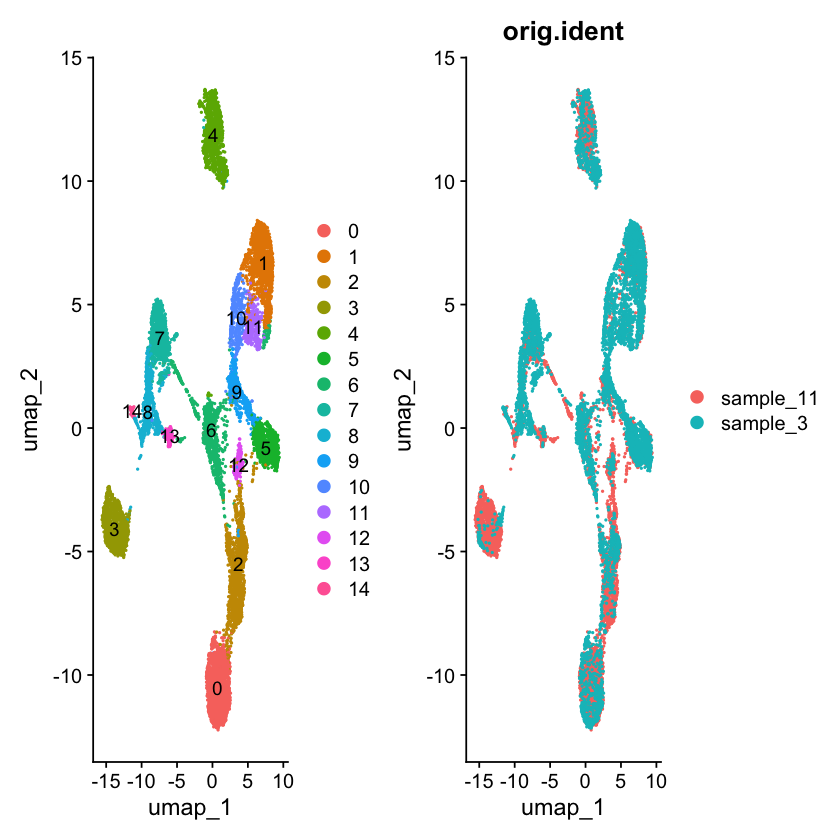

In [20]:
###问题 harmony之后的数据在哪里？


###一定要指定harmony
scRNA_harmony <- FindNeighbors(scRNA_harmony, 
                               reduction = "harmony", 
                               dims = 1:15) %>% FindClusters(resolution = 0.5)

scRNA_harmony <- RunUMAP(scRNA_harmony, reduction = "harmony", dims = 1:16)
# ?DimPlot
plot1 =DimPlot(scRNA_harmony, reduction = "umap",label = T) 
plot2 = DimPlot(scRNA_harmony, reduction = "umap", group.by='orig.ident') 
#combinate
plotc <- plot1+plot2
plotc

16:33:13 UMAP embedding parameters a = 0.9922 b = 1.112

16:33:13 Read 12457 rows and found 16 numeric columns

16:33:13 Using Annoy for neighbor search, n_neighbors = 30

16:33:13 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:33:13 Writing NN index file to temp file /var/folders/9d/07pjf8p54vb0cjnyp1ql9j2m0000gn/T//RtmpGePlPB/filec46c1a587fc9

16:33:13 Searching Annoy index using 1 thread, search_k = 3000

16:33:15 Annoy recall = 100%

16:33:16 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

16:33:16 Initializing from normalized Laplacian + noise (using RSpectra)

16:33:16 Commencing optimization for 200 epochs, with 522990 positive edges

16:33:16 Using rng type: pcg

16:33:20 Optimization finished



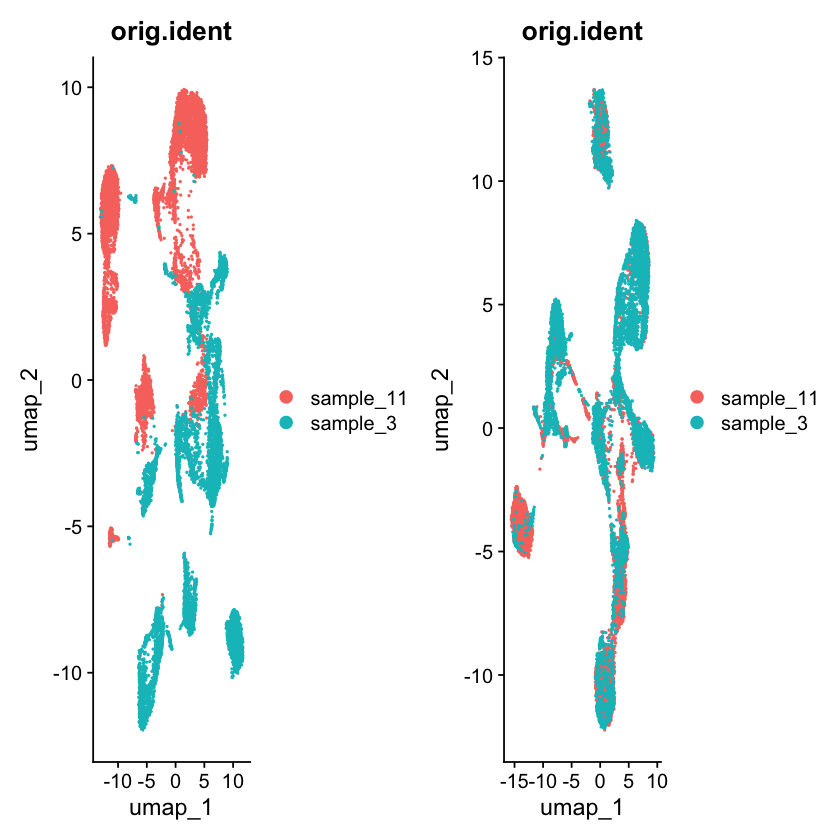

In [ ]:
#### 不整合数据查看对比

scRNA_harmony.1 <- RunUMAP(scRNA_harmony, reduction = "pca", dims = 1:16)
plot1 =DimPlot(scRNA_harmony.1, reduction = "umap",, group.by='orig.ident') 
plot2 = DimPlot(scRNA_harmony, reduction = "umap", group.by='orig.ident') 
#combinate
plotc <- plot1+plot2
plotc

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14

Warning message:
"No DE genes identified"
Warning message:
"The following tests were not performed: "
Warning message:
"When testing 0 versus all:
	data layers are not joined. Please run JoinLayers"
Warning message:
"When testing 1 versus all:
	data layers are not joined. Please run JoinLayers"
Warning message:
"When testing 2 versus all:
	data layers are not joined. Please run JoinLayers"
Warning message:
"When testing 3 versus all:
	data layers are not joined. Please run JoinLayers"
Warning message:
"When testing 4 versus all:
	data layers are not joined. Please run JoinLayers"
Warning message:
"When testing 5 versus all:
	data layers are n

In [24]:
str(markers)

'data.frame':	0 obs. of  0 variables
